# EEG Epoch Extraction

## Purpose
This notebook extracts balanced 2-second EEG epochs for subsequent feature extraction and machine learning.

Workflow:
1. Load each preprocessed EEG recording and its annotation file.
2. Divide sufficiently long SWD events into consecutive 2-second epochs.
3. Identify candidate non-SWD regions outside a 2-second buffer surrounding every SWD.
4. Randomly sample an equal number of non-SWD epochs to create a balanced dataset.
5. Save the epochs and generate a quality-control report.

Outputs:
- MNE Epochs files (.fif)
- Text report summarising the number of SWD and non-SWD epochs extracted from each recording.


In [5]:
# Import required libraries.
# The working directory is displayed to confirm where outputs will be written.

import os 
os.getcwd()

'/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW'

In [ ]:
# Define the main epoch extraction function.
# This function loads the EEG recording and annotations, extracts balanced
# SWD and non-SWD epochs, and returns both the epochs object and a
# summary report describing the extraction process.

import os
import mne
import numpy as np

def make_epochs_from_swd(
    eeg_path,
    ann_path,
    epoch_length_sec=2.0,
    buffer_sec=2.0,          # buffer zone around SWDs (seconds)
    random_state=0
):
    """
    Create balanced SWD (1) and non-SWD (0) epochs from one EEG recording.

    SWD epochs are created by splitting each SWD interval into as many
    consecutive epoch_length_sec windows as fit fully inside the interval.

    SWD intervals shorter than epoch_length_sec are discarded and reported.

    Non-SWD epochs are sampled away from SWD intervals PLUS a buffer zone.
    """

    # 1. Load EEG
    raw = mne.io.read_raw_edf(eeg_path, preload=True)

    # Basic preprocessing (for consistency)
    if "ECG" in raw.ch_names:
        raw.set_channel_types({"ECG": "ecg"})
    raw.set_montage("standard_1020", on_missing="ignore")
    raw.set_eeg_reference("average")
    raw.filter(1., 40.)
    raw.notch_filter(50)

    # Epoch sizing (exact samples)
    sfreq = raw.info["sfreq"]
    samples_per_epoch = int(round(epoch_length_sec * sfreq))
    tmax_epoch = epoch_length_sec - (1.0 / sfreq)

    # 2. Load SWD annotations 
    ann = mne.read_annotations(ann_path)
    raw.set_annotations(ann)

    # 3. Create SWD epochs (label = 1) 
    swd = raw.annotations[raw.annotations.description == "SWD"]

    swd_starts = (swd.onset * sfreq).astype(int)
    swd_ends = ((swd.onset + swd.duration) * sfreq).astype(int)

    swd_epoch_starts = []
    discarded_swd = []  # report discarded short SWDs

    for onset_sec, dur_sec, s0, e0 in zip(swd.onset, swd.duration, swd_starts, swd_ends):
        dur_samp = e0 - s0

        # DISCARD if shorter than one full epoch
        if dur_samp < samples_per_epoch:
            discarded_swd.append({
                "onset_sec": float(onset_sec),
                "duration_sec": float(dur_sec),
                "duration_samples": int(dur_samp),
                "reason": f"shorter than {epoch_length_sec:.3f}s"
            })
            continue

        # Take as many full, non-overlapping epochs as fit inside the SWD interval
        start = s0
        while start + samples_per_epoch <= e0:
            swd_epoch_starts.append(start)
            start += samples_per_epoch

    if len(swd_epoch_starts) == 0:
        raise ValueError(
            "No SWD epochs created (all SWDs shorter than epoch length, or no SWDs found)."
        )

    events_swd = np.c_[
        np.array(swd_epoch_starts, dtype=int),
        np.zeros(len(swd_epoch_starts), dtype=int),
        np.ones(len(swd_epoch_starts), dtype=int),
    ]
    events_swd = events_swd[np.argsort(events_swd[:, 0])]

    epochs_swd = mne.Epochs(
        raw,
        events_swd,
        event_id={"SWD": 1},
        tmin=0,
        tmax=tmax_epoch,
        baseline=None,
        preload=True
    )

    # 4. Create non-SWD epochs (label = 0) 
    # make buffered "forbidden" SWD intervals for negative sampling
    buffer_samp = int(round(buffer_sec * sfreq))
    swd_starts_buf = np.maximum(0, swd_starts - buffer_samp)
    swd_ends_buf = np.minimum(raw.n_times, swd_ends + buffer_samp)

    n_neg = len(epochs_swd)
    starts = []

    rng = np.random.default_rng(random_state)
    max_start = raw.n_times - samples_per_epoch
    max_tries = n_neg * 500
    tries = 0

    while len(starts) < n_neg and tries < max_tries:
        s = int(rng.integers(0, max_start + 1))
        tries += 1

        # check overlap against buffered intervals (not raw SWD intervals)
        overlap = any(
            (s < e) and (s + samples_per_epoch > b)
            for b, e in zip(swd_starts_buf, swd_ends_buf)
        )

        if not overlap:
            starts.append(s)

    if len(starts) < n_neg:
        print(f"Warning: only found {len(starts)} non-SWD epochs (requested {n_neg}).")

    events_non = np.c_[
        np.array(starts, dtype=int),
        np.zeros(len(starts), int),
        np.zeros(len(starts), int)
    ]
    events_non = events_non[np.argsort(events_non[:, 0])]

    epochs_non = mne.Epochs(
        raw,
        events_non,
        event_id={"non_SWD": 0},
        tmin=0,
        tmax=tmax_epoch,
        baseline=None,
        preload=True
    )

    #  5. Combine and return 
    epochs = mne.concatenate_epochs([epochs_swd, epochs_non])

    report = {
        "eeg_path": eeg_path,
        "ann_path": ann_path,
        "epoch_length_sec": float(epoch_length_sec),
        "buffer_sec": float(buffer_sec),          # report buffer
        "sfreq": float(sfreq),
        "n_swd_intervals": int(len(swd)),
        "n_swd_epochs": int(len(epochs_swd)),
        "n_non_swd_epochs": int(len(epochs_non)),
        "n_discarded_swd_intervals": int(len(discarded_swd)),
        "discarded_swd": discarded_swd
    }

    return epochs, report

# Define your EEG files and annotation files

In [7]:
# Specify the EEG recordings and their corresponding annotation files.
# The order of the two lists must match so that each recording is paired
# with the correct annotation file.

eeg_files = [
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P001/EEG/export/20150122AC0003-edf_chin.edf',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P001/EEG/export/20150122AC0004-edf_chin.edf',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P001/EEG/export/20150122AC0005-edf_chin.edf', 
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P002/EEG/export/20150202AM0002-edf_chin.edf',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P002/EEG/export/20150202AM0003-edf_chin.edf',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P002/EEG/export/20150202AM0004-edf_chin.edf',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P003/EEG/export/20131120FD_ICH0003-edf_chin.edf',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P003/EEG/export/20131120FD_ICH0005-edf_chin.edf',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P003/EEG/export/20131120FD_ICH0007-edf_chin.edf',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P004/EEG/export/20140801HF0002-edf_chin.edf',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P004/EEG/export/20140801HF0003-edf_chin.edf',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P004/EEG/export/20140801HF0004-edf_chin.edf',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P005/EEG/export/20130821LH_ICH0004-edf_chin.edf',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P005/EEG/export/20130821LH_ICH0006-edf_chin.edf',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P005/EEG/export/20130821LH_ICH0008-edf_chin.edf'

    # ...
]

ann_files = [
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/AC0003_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/AC0004_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/AC0005_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/AM0002_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/AM0003_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/AM0004_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/FD0003_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/FD0005_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/FD0007_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/HF0002_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/HF0003_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/HF0004_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/LH0004_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/LH0006_SWD_annotations.fif',
    '/Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/ANNOTATIONS/LH0008_SWD_annotations.fif'
    # ...
]

# Create output folders

In [ ]:
# Create output folders if they do not already exist.

os.makedirs("epochs", exist_ok=True)
os.makedirs("reports", exist_ok=True)

# Loop through files → create epochs → save

In [9]:
# Process every EEG recording.
# For each recording, generate balanced epochs, save them to disk,
# and store summary statistics for the final report.

all_reports = []

for eeg_path, ann_path in zip(eeg_files, ann_files):
    print(f"\nProcessing {eeg_path}")

    epochs, report = make_epochs_from_swd(
        eeg_path=eeg_path,
        ann_path=ann_path,
        epoch_length_sec=2.0,
        buffer_sec=2.0
    )

    # Save epochs
    subj = os.path.basename(eeg_path).replace(".edf", "")
    epochs_path = f"epochs/{subj}_epochs-epo.fif"
    epochs.save(epochs_path, overwrite=True)

    print(
        f"Saved {epochs_path} | "
        f"SWD epochs: {report['n_swd_epochs']} | "
        f"non-SWD epochs: {report['n_non_swd_epochs']} | "
        f"discarded SWDs: {report['n_discarded_swd_intervals']}"
    )

    all_reports.append(report)


Processing /Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P001/EEG/export/20150122AC0003-edf_chin.edf
Extracting EDF parameters from /Users/phoebekusi-yeboah/Desktop/AB DISS/GSW/P001/EEG/export/20150122AC0003-edf_chin.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 168499  =      0.000 ...   673.996 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 s

/var/folders/wg/5rcqnk8978v55y85qslh_jfm0000gn/T/ipykernel_8451/1785673681.py:141: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs([epochs_swd, epochs_non])


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower pass

/var/folders/wg/5rcqnk8978v55y85qslh_jfm0000gn/T/ipykernel_8451/1785673681.py:141: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs([epochs_swd, epochs_non])


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower pass

...

/var/folders/wg/5rcqnk8978v55y85qslh_jfm0000gn/T/ipykernel_8451/1785673681.py:141: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs([epochs_swd, epochs_non])


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower pass

/var/folders/wg/5rcqnk8978v55y85qslh_jfm0000gn/T/ipykernel_8451/1785673681.py:141: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs([epochs_swd, epochs_non])


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower pass

/var/folders/wg/5rcqnk8978v55y85qslh_jfm0000gn/T/ipykernel_8451/1785673681.py:141: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs([epochs_swd, epochs_non])


# Save reports to a text file

In [ ]:
# Write a text report summarising the sample ("epoch") extraction performed for
# every recording. This provides a simple quality-control record.

with open("reports/epoch_generation_report.txt", "w") as f:
    for r in all_reports:
        f.write(f"{r['eeg_path']}\n")
        f.write(f"  SWD intervals: {r['n_swd_intervals']}\n")
        f.write(f"  SWD epochs: {r['n_swd_epochs']}\n")
        f.write(f"  non-SWD epochs: {r['n_non_swd_epochs']}\n")
        f.write(f"  discarded SWDs: {r['n_discarded_swd_intervals']}\n")
        f.write(f"  buffer_sec: {r['buffer_sec']}\n\n")

# Checking morphology is correct ( plot)

In [ ]:
# Quality-control step.
# Load a representative sample file and visually inspect the extracted
# epochs to confirm that the SWD morphology has been preserved.

import mne

epochs = mne.read_epochs('/Users/phoebekusi-yeboah/Desktop/AB_DISS/GSW/epochs_2/AC0005-edf_chin_epochs-epo.fif', preload=True)
print(epochs)
print(epochs.event_id)   # should show {"SWD":1, "non_SWD":0} (or similar)

Reading /Users/phoebekusi-yeboah/Desktop/AB_DISS/GSW/epochs_2/AC0005-edf_chin_epochs-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    1996.00 ms
        0 CTF compensation matrices available
Not setting metadata
46 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 46 events (all good), 0 – 1.996 s (baseline off), ~11.3 MiB, data loaded,
 'SWD': 23
 'non_SWD': 23>
{'SWD': 1, 'non_SWD': 0}


In [3]:
# Separate the two classes for independent visual inspection.

epochs_swd = epochs["SWD"]
epochs_non = epochs["non_SWD"]   

print(len(epochs_swd), len(epochs_non))

23 23


Using matplotlib as 2D backend.


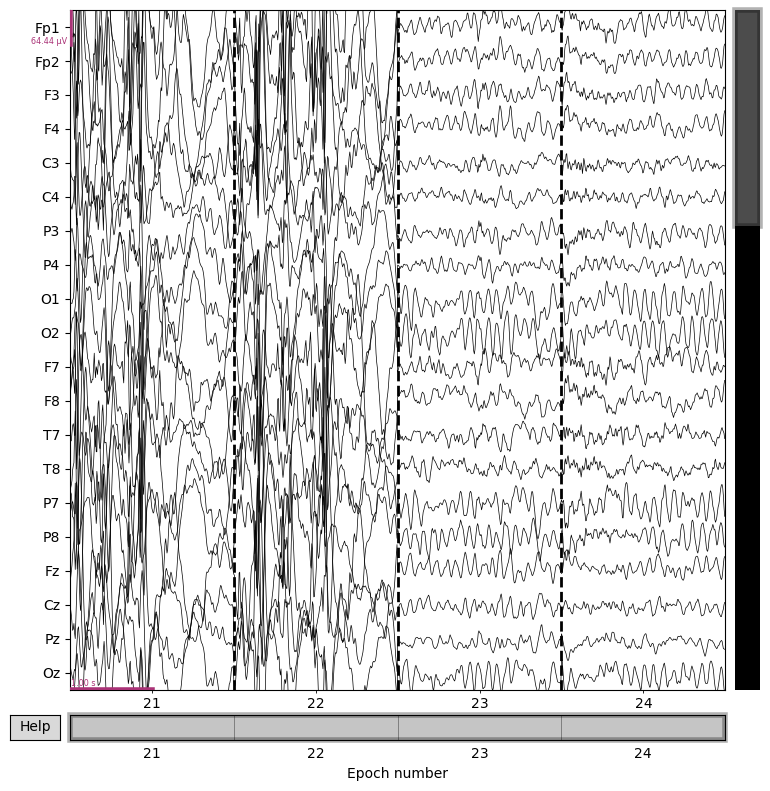

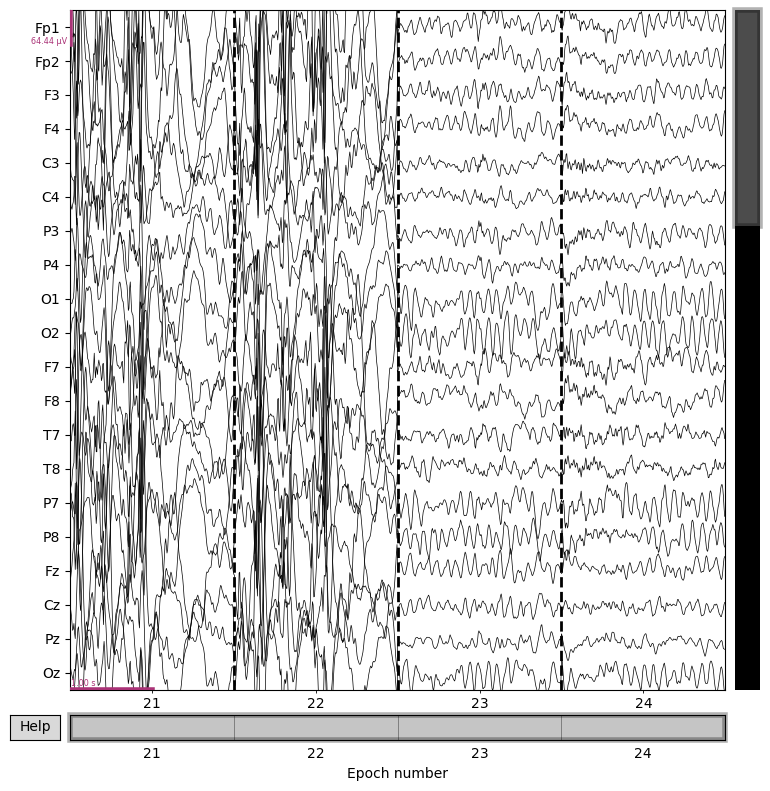

In [ ]:
# Display the last two SWD and first two non-SWD samples to verify correct extraction.

epochs[21:25].plot(
    n_epochs=4,      # show 10 at a time
    n_channels=20,
    scalings="auto"
)